# CZ Benchmarks Phase 3: Label Prediction Evaluation

This notebook implements Phase 3-5 of the CZ benchmarks evaluation: using CZ's label prediction task to evaluate all embedding combinations and generate comparative analysis.

Based on `specs/cz_benchmarks_evaluation_spec.md`

In [23]:
# Setup notebook environment
%load_ext autoreload
%autoreload 2

import sys
import os
from pathlib import Path

# Add parent directory to path
repo_dir = Path.cwd().parent
if str(repo_dir) not in sys.path:
    sys.path.insert(0, str(repo_dir))

print(f"Repository directory: {repo_dir}")
data_dir = repo_dir / "data"
print(f"Data directory: {data_dir}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Repository directory: /Users/rj/personal/GenePT-tools
Data directory: /Users/rj/personal/GenePT-tools/data


In [24]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from pathlib import Path
from tqdm.auto import tqdm
from dataclasses import dataclass, field
from typing import List, Dict
import warnings
warnings.filterwarnings('ignore')

# CZ Benchmarks imports
from czbenchmarks.tasks.label_prediction import MetadataLabelPredictionTask

print("✓ All imports successful")

✓ All imports successful


## Configuration

In [25]:
@dataclass
class CZBenchmarkConfig:
    """Configuration for CZ benchmarks evaluation"""
    tissue_types: List[str] = field(default_factory=lambda: [
        'Blood', 'Bone_Marrow', 'Lung', 'Mammary', 'Thymus'
    ])
    embedding_combinations: List[str] = field(default_factory=lambda: [
        'genept_1024d',
        'genept_scgpt',
        'genept_transcriptformer'
    ])
    cv_folds: int = 5
    min_class_size: int = 10
    random_seed: int = 42
    
    # Paths
    benchmark_data_dir: Path = Path("/Users/rj/personal/Tabula_Sapiens_v2_Curated_Benchmark")
    embedding_dir: Path = data_dir / 'cz_benchmark' / 'embeddings' / 'combined'
    results_dir: Path = data_dir / 'cz_benchmark' / 'results'

config = CZBenchmarkConfig()
config.results_dir.mkdir(parents=True, exist_ok=True)

print("Configuration:")
print(f"  Tissues: {config.tissue_types}")
print(f"  Embeddings: {config.embedding_combinations}")
print(f"  CV folds: {config.cv_folds}")
print(f"  Results dir: {config.results_dir}")

Configuration:
  Tissues: ['Blood', 'Bone_Marrow', 'Lung', 'Mammary', 'Thymus']
  Embeddings: ['genept_1024d', 'genept_scgpt', 'genept_transcriptformer']
  CV folds: 5
  Results dir: /Users/rj/personal/GenePT-tools/data/cz_benchmark/results


## Data Loading Functions

In [26]:
def load_tabula_sapiens_dataset(tissue_name: str, config: CZBenchmarkConfig) -> ad.AnnData:
    """Load Tabula Sapiens v2 curated dataset."""
    # Files are named: homo_sapiens_{uuid}_{tissue}_v2_curated.h5ad
    pattern = f"*_{tissue_name}_v2_curated.h5ad"
    files = list(config.benchmark_data_dir.glob(pattern))
    
    if not files:
        raise FileNotFoundError(f"No h5ad file found for tissue: {tissue_name}")
    
    file_path = files[0]
    print(f"Loading {tissue_name} from: {file_path.name}")
    
    adata = sc.read_h5ad(file_path)
    
    # Handle layers - Tabula Sapiens v2 stores data in X_original layer
    if adata.X is None or (hasattr(adata.X, 'nnz') and adata.X.nnz == 0):
        if 'X_original' in adata.layers:
            adata.X = adata.layers['X_original'].copy()
        else:
            raise ValueError(f"No expression data found in adata.X or adata.layers['X_original']")
    
    # Ensure cell_type column exists
    if 'cell_type' not in adata.obs.columns:
        for col in ['cell_ontology_class', 'celltype', 'CellType', 'free_annotation']:
            if col in adata.obs.columns:
                adata.obs['cell_type'] = adata.obs[col]
                print(f"Using column '{col}' as cell_type")
                break
    
    print(f"  Loaded: {adata.n_obs} cells, {adata.n_vars} genes, {adata.obs['cell_type'].nunique()} cell types")
    
    return adata

def load_combined_embeddings(tissue_name: str, embedding_name: str, config: CZBenchmarkConfig) -> tuple:
    """Load combined embeddings and return (embeddings_array, cell_ids)."""
    embedding_path = config.embedding_dir / f"{embedding_name}_{tissue_name}_embeddings.parquet"
    
    if not embedding_path.exists():
        raise FileNotFoundError(f"Embedding file not found: {embedding_path}")
    
    df = pd.read_parquet(embedding_path)
    
    # Extract cell IDs from index
    cell_ids = df.index.values
    
    # Extract embedding columns
    emb_cols = [col for col in df.columns if col.startswith(embedding_name)]
    embeddings = df[emb_cols].values
    
    print(f"  Loaded {embedding_name}: {embeddings.shape}")
    
    return embeddings, cell_ids

## CZ Label Prediction Task Wrapper

In [27]:
def run_cz_label_prediction(embeddings: np.ndarray, adata: ad.AnnData, config: CZBenchmarkConfig) -> Dict:
    """
    Run CZ label prediction task with standardized parameters.
    
    Args:
        embeddings: Cell embeddings as numpy array (n_cells, n_dims)
        adata: AnnData object with cell_type labels in obs
        config: Benchmark configuration
    
    Returns:
        Dict with metrics from CZ benchmarks task
    """
    from czbenchmarks.tasks.label_prediction import MetadataLabelPredictionTaskInput
    
    print(f"  Running CZ label prediction task...")
    print(f"    Embeddings: {embeddings.shape}")
    print(f"    Labels: {adata.n_obs} cells, {adata.obs['cell_type'].nunique()} cell types")
    
    # Initialize task (only takes random_seed)
    task = MetadataLabelPredictionTask(random_seed=config.random_seed)
    
    # Convert labels to numpy array (handle pandas Categorical)
    labels = np.asarray(adata.obs['cell_type'])
    
    # Create task input with n_folds and min_class_size
    task_input = MetadataLabelPredictionTaskInput(
        labels=labels,
        n_folds=config.cv_folds,
        min_class_size=config.min_class_size
    )
    
    # Run task with embeddings and task_input
    results = task.run(
        cell_representation=embeddings,
        task_input=task_input
    )
    
    print(f"    ✓ Task complete - {len(results)} metrics returned")
    
    return results

## Evaluation Pipeline

In [28]:
def evaluate_tissue_embedding_combination(
    tissue_name: str,
    embedding_name: str,
    config: CZBenchmarkConfig
) -> Dict:
    """
    Evaluate a single tissue-embedding combination.
    """
    print(f"\n{'='*80}")
    print(f"Tissue: {tissue_name} | Embedding: {embedding_name}")
    print('='*80)
    
    try:
        # Load AnnData for labels
        adata = load_tabula_sapiens_dataset(tissue_name, config)
        
        # Load embeddings
        embeddings, cell_ids = load_combined_embeddings(tissue_name, embedding_name, config)
        
        # Verify alignment: embeddings should be in same order as adata
        # Cell IDs from embeddings should match adata cell IDs
        adata_cell_ids = adata.obs_names.values
        if not np.array_equal(cell_ids, adata_cell_ids):
            # Try to align
            print(f"  Warning: Cell order mismatch, attempting to align...")
            # Create mapping from cell_id to row index in embeddings
            cell_id_to_idx = {cid: idx for idx, cid in enumerate(cell_ids)}
            # Reorder embeddings to match adata
            aligned_indices = [cell_id_to_idx[cid] for cid in adata_cell_ids if cid in cell_id_to_idx]
            embeddings = embeddings[aligned_indices]
            # Subset adata to only cells we have embeddings for
            adata = adata[[cid in cell_id_to_idx for cid in adata_cell_ids], :]
            print(f"  Aligned to {len(aligned_indices)} cells")
        
        # Run CZ label prediction
        results = run_cz_label_prediction(embeddings, adata, config)
        
        # Parse results - CZ returns list of MetricResult objects
        result_dict = {
            'tissue': tissue_name,
            'embedding': embedding_name,
            'n_cells': adata.n_obs,
            'n_cell_types': adata.obs['cell_type'].nunique(),
            'embedding_dims': embeddings.shape[1],
            'status': 'success'
        }
        
        # Extract metrics from CZ results (list of MetricResult objects)
        for metric_result in results:
            metric_name = str(metric_result.metric_type.value)
            metric_value = metric_result.value
            classifier = metric_result.params.get('classifier', 'unknown')
            
            # Create column name with classifier info
            col_name = f"{metric_name}_{classifier}"
            result_dict[col_name] = metric_value
            
            # Also save the main mean metrics without classifier suffix for easier access
            if 'MEAN(' in classifier:
                result_dict[metric_name] = metric_value
        
        print(f"  ✓ Evaluation complete")
        
        return result_dict
        
    except Exception as e:
        print(f"  ✗ Error: {str(e)}")
        import traceback
        traceback.print_exc()
        
        return {
            'tissue': tissue_name,
            'embedding': embedding_name,
            'status': 'failed',
            'error': str(e)
        }

## Run Complete Evaluation

In [29]:
# Run evaluation for all combinations
all_results = []

for tissue_name in tqdm(config.tissue_types, desc="Processing tissues"):
    for embedding_name in config.embedding_combinations:
        result = evaluate_tissue_embedding_combination(
            tissue_name,
            embedding_name,
            config
        )
        all_results.append(result)

print(f"\n{'='*80}")
print("EVALUATION COMPLETE")
print('='*80)
print(f"Total evaluations: {len(all_results)}")
print(f"Successful: {sum(1 for r in all_results if r['status'] == 'success')}")
print(f"Failed: {sum(1 for r in all_results if r['status'] == 'failed')}")

Processing tissues:   0%|          | 0/5 [00:00<?, ?it/s]


Tissue: Blood | Embedding: genept_1024d
Loading Blood from: homo_sapiens_10df7690-6d10-4029-a47e-0f071bb2df83_Blood_v2_curated.h5ad
  Loaded: 17802 cells, 27284 genes, 19 cell types


INFO:czbenchmarks.tasks.label_prediction:Starting prediction task for labels
INFO:czbenchmarks.tasks.label_prediction:Initial data shape: (17802, 1024), labels shape: (17802,)
INFO:czbenchmarks.tasks.utils:Label composition (unknown):
INFO:czbenchmarks.tasks.utils:Total classes before filtering: 19
INFO:czbenchmarks.tasks.utils:Total classes after filtering (min_class_size=10): 16
INFO:czbenchmarks.tasks.label_prediction:After filtering: (17788, 1024) samples remaining
INFO:czbenchmarks.tasks.label_prediction:Found 16 classes, using macro averaging for metrics
INFO:czbenchmarks.tasks.label_prediction:Using 5-fold cross validation with random_seed 42
INFO:czbenchmarks.tasks.label_prediction:Created classifiers: ['lr', 'knn', 'rf']
INFO:czbenchmarks.tasks.label_prediction:Running cross-validation for lr...


  Loaded genept_1024d: (17802, 1024)
  Running CZ label prediction task...
    Embeddings: (17802, 1024)
    Labels: 17802 cells, 19 cell types


INFO:czbenchmarks.tasks.label_prediction:Running cross-validation for knn...
INFO:czbenchmarks.tasks.label_prediction:Running cross-validation for rf...
INFO:czbenchmarks.tasks.label_prediction:Completed cross-validation for all classifiers
INFO:czbenchmarks.tasks.label_prediction:Computing final metrics...


...

    ✓ Task complete - 20 metrics returned
  ✓ Evaluation complete

Tissue: Thymus | Embedding: genept_transcriptformer
Loading Thymus from: homo_sapiens_10df7690-6d10-4029-a47e-0f071bb2df83_Thymus_v2_curated.h5ad
  Loaded: 9933 cells, 30453 genes, 27 cell types


INFO:czbenchmarks.tasks.label_prediction:Starting prediction task for labels
INFO:czbenchmarks.tasks.label_prediction:Initial data shape: (9933, 3072), labels shape: (9933,)
INFO:czbenchmarks.tasks.utils:Label composition (unknown):
INFO:czbenchmarks.tasks.utils:Total classes before filtering: 27
INFO:czbenchmarks.tasks.utils:Total classes after filtering (min_class_size=10): 22
INFO:czbenchmarks.tasks.label_prediction:After filtering: (9912, 3072) samples remaining
INFO:czbenchmarks.tasks.label_prediction:Found 22 classes, using macro averaging for metrics
INFO:czbenchmarks.tasks.label_prediction:Using 5-fold cross validation with random_seed 42
INFO:czbenchmarks.tasks.label_prediction:Created classifiers: ['lr', 'knn', 'rf']
INFO:czbenchmarks.tasks.label_prediction:Running cross-validation for lr...


  Loaded genept_transcriptformer: (9933, 3072)
  Running CZ label prediction task...
    Embeddings: (9933, 3072)
    Labels: 9933 cells, 27 cell types


INFO:czbenchmarks.tasks.label_prediction:Running cross-validation for knn...
INFO:czbenchmarks.tasks.label_prediction:Running cross-validation for rf...
INFO:czbenchmarks.tasks.label_prediction:Completed cross-validation for all classifiers
INFO:czbenchmarks.tasks.label_prediction:Computing final metrics...


    ✓ Task complete - 20 metrics returned
  ✓ Evaluation complete

EVALUATION COMPLETE
Total evaluations: 15
Successful: 15
Failed: 0


## Results Analysis

In [30]:
# Convert results to DataFrame
results_df = pd.DataFrame(all_results)

# Save raw results
results_file = config.results_dir / 'cz_benchmarks_results.csv'
results_df.to_csv(results_file, index=False)
print(f"Saved results to: {results_file}")

# Display summary
print("\n=== Results Summary ===")
print(results_df.to_string(index=False))

Saved results to: /Users/rj/personal/GenePT-tools/data/cz_benchmark/results/cz_benchmarks_results.csv

=== Results Summary ===
     tissue               embedding  n_cells  n_cell_types  embedding_dims  status  mean_fold_accuracy_MEAN(knn,lr,rf)  mean_fold_accuracy  mean_fold_f1_MEAN(knn,lr,rf)  mean_fold_f1  mean_fold_precision_MEAN(knn,lr,rf)  mean_fold_precision  mean_fold_recall_MEAN(knn,lr,rf)  mean_fold_recall  mean_fold_auroc_MEAN(knn,lr,rf)  mean_fold_auroc  mean_fold_accuracy_lr  mean_fold_f1_lr  mean_fold_precision_lr  mean_fold_recall_lr  mean_fold_auroc_lr  mean_fold_accuracy_knn  mean_fold_f1_knn  mean_fold_precision_knn  mean_fold_recall_knn  mean_fold_auroc_knn  mean_fold_accuracy_rf  mean_fold_f1_rf  mean_fold_precision_rf  mean_fold_recall_rf  mean_fold_auroc_rf
      Blood            genept_1024d    17802            19            1024 success                            0.873904            0.873904                      0.732898      0.732898                            

In [31]:
# Create performance comparison table
if 'mean_fold_accuracy' in results_df.columns:
    print("\n=== Performance by Tissue and Embedding ===")
    pivot_table = results_df[results_df['status'] == 'success'].pivot_table(
        index='tissue',
        columns='embedding',
        values='mean_fold_accuracy',
        aggfunc='mean'
    )
    print(pivot_table.to_string())
    
    # Calculate improvements
    print("\n=== Improvement from Combining Embeddings ===")
    if 'genept_1024d' in pivot_table.columns:
        baseline = pivot_table['genept_1024d']
        
        for col in ['genept_scgpt', 'genept_transcriptformer']:
            if col in pivot_table.columns:
                improvement = pivot_table[col] - baseline
                print(f"\n{col} vs genept_1024d:")
                print(improvement.to_string())
                print(f"Mean improvement: {improvement.mean():.4f}")
else:
    print("No mean_fold_accuracy metric found in results")
    print("Available columns:", results_df.columns.tolist())


=== Performance by Tissue and Embedding ===
embedding    genept_1024d  genept_scgpt  genept_transcriptformer
tissue                                                          
Blood            0.873904      0.899820                 0.905442
Bone_Marrow      0.836176      0.864774                 0.869256
Lung             0.907576      0.932575                 0.940463
Mammary          0.986726      0.992877                 0.991168
Thymus           0.834578      0.878262                 0.909269

=== Improvement from Combining Embeddings ===

genept_scgpt vs genept_1024d:
tissue
Blood          0.025916
Bone_Marrow    0.028597
Lung           0.024999
Mammary        0.006152
Thymus         0.043684
Mean improvement: 0.0259

genept_transcriptformer vs genept_1024d:
tissue
Blood          0.031538
Bone_Marrow    0.033080
Lung           0.032886
Mammary        0.004443
Thymus         0.074691
Mean improvement: 0.0353


## Visualization

Saved figure to: /Users/rj/personal/GenePT-tools/data/cz_benchmark/results/cz_benchmarks_performance.png


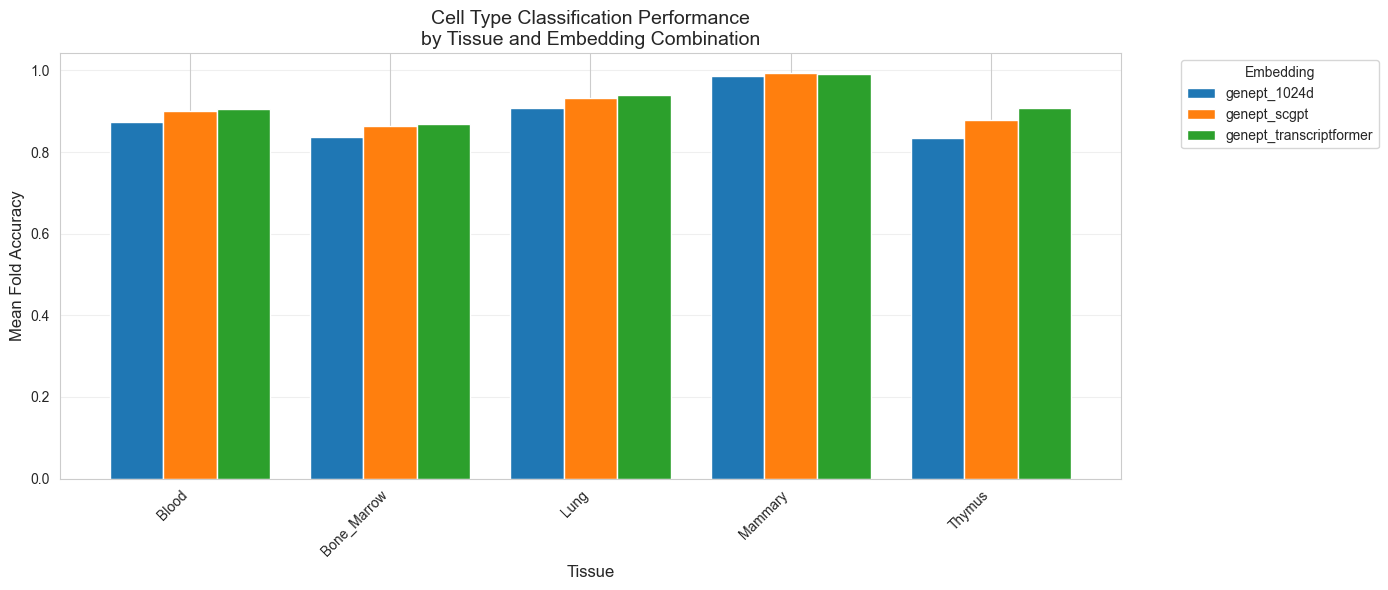

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Plot performance by tissue and embedding
if 'mean_fold_accuracy' in results_df.columns:
    successful_results = results_df[results_df['status'] == 'success']
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Create grouped bar plot
    pivot_data = successful_results.pivot_table(
        index='tissue',
        columns='embedding',
        values='mean_fold_accuracy'
    )
    
    pivot_data.plot(kind='bar', ax=ax, width=0.8)
    ax.set_xlabel('Tissue', fontsize=12)
    ax.set_ylabel('Mean Fold Accuracy', fontsize=12)
    ax.set_title('Cell Type Classification Performance\nby Tissue and Embedding Combination', fontsize=14)
    ax.legend(title='Embedding', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    # Save figure
    fig_path = config.results_dir / 'cz_benchmarks_performance.png'
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"Saved figure to: {fig_path}")
    
    plt.show()
else:
    print("No mean_fold_accuracy metric found in results")
    print("Cannot create visualization")

In [33]:
print("\n" + "="*80)
print("CZ BENCHMARKS EVALUATION COMPLETE")
print("="*80)
print(f"Results saved to: {config.results_dir}")
print(f"  - CSV: {results_file.name}")
if 'mean_fold_accuracy' in results_df.columns:
    print(f"  - Figure: cz_benchmarks_performance.png")
print("\nPhases 3-5 Complete!")


CZ BENCHMARKS EVALUATION COMPLETE
Results saved to: /Users/rj/personal/GenePT-tools/data/cz_benchmark/results
  - CSV: cz_benchmarks_results.csv
  - Figure: cz_benchmarks_performance.png

Phases 3-5 Complete!
